## 1. Descargar Dataset PlantNet-300K (~31 GB)

**Nota:** Esta celda descarga el dataset completo desde Zenodo. Solo se ejecuta si el dataset no existe. La descarga puede tardar varias horas dependiendo de tu conexión.

In [15]:

"""
Descarga automática del dataset PlantNet-300K desde Zenodo.
El dataset completo tiene ~31GB. Se descargará solo si no existe.
"""

import os
import requests
import zipfile

# CONFIGURAR: Directorio donde se descargará el dataset
DATASET_NAME = "plantnet_300K"
DATASET_PATH = os.path.join(DATASET_NAME)
print(DATASET_PATH)
# URL del dataset en Zenodo
ZENODO_URL = "https://zenodo.org/records/5645731/files/plantnet300K.zip?download=1"

def download_file(url, dest_path, chunk_size=1024*1024):
    """Descarga un archivo con barra de progreso"""
    response = requests.get(url, stream=True)
    response.raise_for_status()
    
    total_size = int(response.headers.get('content-length', 0))
    downloaded = 0
    
    print(f"Descargando: {os.path.basename(dest_path)}")
    print(f"Tamaño total: {total_size / 1024**3:.2f} GB")
    print("=" * 60)
    
    with open(dest_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)
                if total_size > 0:
                    percent = (downloaded / total_size) * 100
                    print(f"\rProgreso: {percent:.1f}% ({downloaded / 1024**3:.2f} GB / {total_size / 1024**3:.2f} GB)", end='', flush=True)
    print("\n" + "=" * 60)
    print("Descarga completada ✓")

def extract_zip(zip_path, extract_to):
    """Extrae un archivo ZIP con progreso"""
    print(f"\nExtrayendo: {os.path.basename(zip_path)}")
    print("Esto puede tardar varios minutos...")
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    
    print("Extracción completada ✓")

# Verificar si el dataset ya existe
if os.path.isdir(DATASET_PATH):
    print(f"Dataset encontrado en: {DATASET_PATH}")
    print("Omitiendo descarga ✓")
else:
    print("Dataset no encontrado. Iniciando descarga...")
    print("=" * 60)
    
    # Crear directorio si no existe
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    
    # Descargar ZIP
    zip_path = os.path.join(DOWNLOAD_DIR, "plantnet300K.zip")
    
    try:
        download_file(ZENODO_URL, zip_path)
        
        # Extraer
        extract_zip(zip_path, DOWNLOAD_DIR)
        
        # Eliminar ZIP para ahorrar espacio
        print("\nEliminando archivo ZIP para ahorrar espacio...")
        os.remove(zip_path)
        print("ZIP eliminado ✓")
        
        print("\n" + "=" * 60)
        print("DATASET LISTO PARA USAR ✓")
        print(f"Ubicación: {DATASET_PATH}")
        print("=" * 60)
        
    except Exception as e:
        print(f"\nError durante la descarga: {e}")
        print("\nAlternativa: Descarga manual desde:")
        print("https://zenodo.org/records/5645731")
        raise

# Verificar contenido
if os.path.exists(DATASET_PATH):
    print(f"\nContenido del dataset:")
    items = os.listdir(DATASET_PATH)[:10]
    for item in items:
        print(f"  - {item}")
    if len(os.listdir(DATASET_PATH)) > 10:
        print(f"  ... y {len(os.listdir(DATASET_PATH)) - 10} archivos más")


plantnet_300K
Dataset encontrado en: plantnet_300K
Omitiendo descarga ✓

Contenido del dataset:
  - README
  - plantnet300K_metadata.json
  - plantnet300K_species_id_2_name.json
  - .DS_Store
  - images


# Taxo-Net: Entrenamiento con PlantNet-300K

Este notebook entrena el modelo Taxo-Net (ResNet-50 multirrama) con la pérdida de penalización taxonómica (TPL) en el dataset PlantNet-300K.

**Salida:** `taxonet_best.pth` - modelo entrenado listo para inferencia.

## 1. Verificar CUDA

In [16]:
import torch

print(f"PyTorch versión: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria total: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
    print("¡ADVERTENCIA! Usando CPU. El entrenamiento será muy lento.")
    
print(f"\nDispositivo seleccionado: {DEVICE}")

PyTorch versión: 2.11.0+cu130
CUDA disponible: True
GPU: NVIDIA GeForce RTX 3090
Memoria total: 23.54 GB

Dispositivo seleccionado: cuda


## 2. Importar librerías

In [17]:
import torch; 
print('Torch:', torch.__version__); 
import torchvision; print('Torchvision:', torchvision.__version__)


Torch: 2.11.0+cu130
Torchvision: 0.26.0+cu130


In [18]:
import os
import json
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import Dataset, DataLoader

# Reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Librerías importadas correctamente ✓")

Librerías importadas correctamente ✓


In [19]:
# torch.cuda.empty_cache()

## 3. Configurar paths

In [20]:
# CONFIGURAR: Ruta al dataset PlantNet-300K
ROOT_DIR = "plantnet_300K"

# Verificar que existe
if not os.path.isdir(ROOT_DIR):
    raise FileNotFoundError(f"No se encontró: {ROOT_DIR}")

print(f"Dataset root: {ROOT_DIR}")
print(f"Contenido: {os.listdir(ROOT_DIR)[:5]}...")  # Mostrar primeros archivos

Dataset root: plantnet_300K
Contenido: ['README', 'plantnet300K_metadata.json', 'plantnet300K_species_id_2_name.json', '.DS_Store', 'images']...


## 4. Dataset Jerárquico

In [21]:
class PlantNet300K_Hierarchical(Dataset):
    """
    Cargador que acopla cada imagen con su triplete taxonómico:
    (Familia, Género, Especie)
    """
    
    def __init__(self, root_dir: str, split_type: str = 'train', transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        # Cargar metadatos
        metadata_path = os.path.join(root_dir, 'plantnet300K_metadata.json')
        with open(metadata_path, 'r') as f:
            metadata = json.load(f)

        # Cargar nombres de especies
        names_path = os.path.join(root_dir, 'plantnet300K_species_id_2_name.json')
        with open(names_path, 'r', encoding='utf-8') as nf:
            species_names = json.load(nf)

        # Mapeo de species_id a índice contiguo
        sorted_sids = sorted(int(k) for k in species_names.keys())
        sid_to_idx = {sid: idx for idx, sid in enumerate(sorted_sids)}

        # Construir mapeos taxonómicos
        genus_names_sorted = sorted({n.split('_')[0] for n in species_names.values()})
        genus_name_to_id = {g: i for i, g in enumerate(genus_names_sorted)}
        GENERA_PER_FAMILY = 5

        def _get_ids(species_id_str):
            name = species_names.get(str(species_id_str), '_unknown')
            genus = name.split('_')[0]
            gid = genus_name_to_id.get(genus, 0)
            fid = gid // GENERA_PER_FAMILY
            return fid, gid

        # Cargar muestras del split especificado
        for img_hash, info in metadata.items():
            if info.get('split') == split_type:
                split_folder = f'images/{split_type}'
                sid = int(info['species_id'])
                img_path = os.path.join(
                    root_dir, split_folder,
                    str(info['species_id']),
                    img_hash + '.jpg'
                )
                fid, gid = _get_ids(info['species_id'])
                self.samples.append((img_path, fid, gid, sid_to_idx[sid]))

        print(f"{split_type}: {len(self.samples)} muestras cargadas")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, y_fam, y_gen, y_spec = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, y_fam, y_gen, y_spec

print("Clase Dataset definida ✓")

Clase Dataset definida ✓


## 5. Construir mapas taxonómicos

In [22]:
def build_taxonomy_maps(metadata_path: str):
    """
    Construye diccionarios de mapeo species_id -> genus_id/family_id
    """
    names_path = os.path.join(ROOT_DIR, 'plantnet300K_species_id_2_name.json')
    
    with open(names_path, 'r', encoding='utf-8') as f:
        species_names = json.load(f)
    
    # Mapeo id -> idx
    sorted_sids = sorted(int(k) for k in species_names.keys())
    sid_to_idx = {sid: idx for idx, sid in enumerate(sorted_sids)}
    
    # Mapear species_idx -> genus_name
    sid_to_genus_name = {}
    for sid_str, name in species_names.items():
        genus = name.split('_')[0]
        idx = sid_to_idx[int(sid_str)]
        sid_to_genus_name[idx] = genus
    
    # Asignar genus_id a cada género único
    genus_names_sorted = sorted(set(sid_to_genus_name.values()))
    genus_name_to_id = {g: i for i, g in enumerate(genus_names_sorted)}
    
    # Agrupar géneros en familias sintéticas (bloques de 5)
    GENERA_PER_FAMILY = 5
    genus_id_to_family_id = {gid: gid // GENERA_PER_FAMILY for gid in range(len(genus_names_sorted))}
    
    # Construir mapas finales
    species_to_genus = {}
    species_to_family = {}
    for s_idx, genus_name in sid_to_genus_name.items():
        gid = genus_name_to_id[genus_name]
        fid = genus_id_to_family_id[gid]
        species_to_genus[s_idx] = gid
        species_to_family[s_idx] = fid
    
    num_genera = len(genus_names_sorted)
    num_families = len(set(genus_id_to_family_id.values()))
    
    print(f"Taxonomía: {num_families} familias | {num_genera} géneros | {len(species_to_genus)} especies")
    return species_to_genus, species_to_family, num_families, num_genera

# Ejecutar
metadata_path = os.path.join(ROOT_DIR, 'plantnet300K_metadata.json')
species_to_genus, species_to_family, num_families, num_genera = build_taxonomy_maps(metadata_path)

Taxonomía: 217 familias | 1081 géneros | 1081 especies


## 6. Arquitectura Taxo-Net

In [23]:
class TaxoNet_ResNet50(nn.Module):
    """
    ResNet-50 con tres cabezas de clasificación:
    Familia → Género → Especie
    """
    
    def __init__(self, num_families: int, num_genera: int, num_species: int = 1081, dropout_p: float = 0.4):
        super(TaxoNet_ResNet50, self).__init__()
        
        base_model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.features = nn.Sequential(*list(base_model.children())[:-1])
        hidden_dim = base_model.fc.in_features
        
        self.dropout = nn.Dropout(p=dropout_p)
        self.family_head = nn.Linear(hidden_dim, num_families)
        self.genus_head = nn.Linear(hidden_dim, num_genera)
        self.species_head = nn.Linear(hidden_dim, num_species)
    
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        
        out_family = self.family_head(x)
        out_genus = self.genus_head(x)
        out_species = self.species_head(x)
        
        return out_family, out_genus, out_species

print("Arquitectura Taxo-Net definida ✓")

Arquitectura Taxo-Net definida ✓


## 7. Pérdida Taxonómica (TPL)

In [24]:
class TaxonomicPenaltyLoss(nn.Module):
    """
    L_TPL = α·L_familia + β·L_género + γ·L_especie
    donde γ > β > α (prioriza especie, penaliza errores de familia)
    """
    
    def __init__(self, alpha: float = 0.15, beta: float = 0.25, gamma: float = 0.60):
        super(TaxonomicPenaltyLoss, self).__init__()
        assert abs(alpha + beta + gamma - 1.0) < 1e-6
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.criterion = nn.CrossEntropyLoss()
    
    def forward(self, preds, targets):
        pred_f, pred_g, pred_s = preds
        target_f, target_g, target_s = targets
        
        loss_family = self.criterion(pred_f, target_f)
        loss_genus = self.criterion(pred_g, target_g)
        loss_species = self.criterion(pred_s, target_s)
        
        total_loss = (self.alpha * loss_family + 
                      self.beta * loss_genus + 
                      self.gamma * loss_species)
        return total_loss

print("Pérdida TPL definida ✓")

Pérdida TPL definida ✓


## 8. Funciones de entrenamiento y evaluación

In [25]:
def train_epoch(dataloader, model, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    
    for images, labels_f, labels_g, labels_s in dataloader:
        images = images.to(device)
        labels_f = labels_f.to(device)
        labels_g = labels_g.to(device)
        labels_s = labels_s.to(device)
        
        optimizer.zero_grad()
        preds_f, preds_g, preds_s = model(images)
        loss = criterion((preds_f, preds_g, preds_s), (labels_f, labels_g, labels_s))
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    return running_loss / len(dataloader)


def evaluate(dataloader, model, criterion, device, species_to_genus, species_to_family):
    model.eval()
    running_loss = 0.0
    correct_top1 = 0
    correct_top5 = 0
    total_samples = 0
    tde_total = 0.0
    
    with torch.no_grad():
        for images, labels_f, labels_g, labels_s in dataloader:
            images = images.to(device)
            labels_f = labels_f.to(device)
            labels_g = labels_g.to(device)
            labels_s = labels_s.to(device)
            
            preds_f, preds_g, preds_s = model(images)
            loss = criterion((preds_f, preds_g, preds_s), (labels_f, labels_g, labels_s))
            running_loss += loss.item()
            
            # Métricas
            batch_size = images.size(0)
            total_samples += batch_size
            
            _, top5_preds = preds_s.topk(5, dim=1)
            top1_preds = top5_preds[:, 0]
            
            correct_top1 += (top1_preds == labels_s).sum().item()
            correct_top5 += (top5_preds == labels_s.unsqueeze(1)).any(dim=1).sum().item()
            
            # Taxonomic Distance Error
            for pred_s, true_s in zip(top1_preds.cpu().tolist(), labels_s.cpu().tolist()):
                if pred_s == true_s:
                    tde_total += 0
                elif species_to_genus.get(pred_s) == species_to_genus.get(true_s):
                    tde_total += 1
                elif species_to_family.get(pred_s) == species_to_family.get(true_s):
                    tde_total += 2
                else:
                    tde_total += 3
    
    return {
        'val_loss': running_loss / len(dataloader),
        'top1_acc': correct_top1 / total_samples,
        'top5_acc': correct_top5 / total_samples,
        'mean_tde': tde_total / total_samples
    }

print("Funciones de entrenamiento/evaluación definidas ✓")

Funciones de entrenamiento/evaluación definidas ✓


## 9. Preparar DataLoaders

In [29]:
# Hiperparámetros
BATCH_SIZE = 180  # Reducir si hay poca memoria GPU
DATASET_FRACTION = 0.3  # << Fracción del dataset a usar <<

NUM_WORKERS = 2   # 0 si hay problemas en Windows

# Transforms
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Crear datasets
print("Cargando datasets...")
train_dataset = PlantNet300K_Hierarchical(ROOT_DIR, 'train', train_transform)

# Reducir fracción de entrenamiento dinámicamente
if DATASET_FRACTION < 1.0:
    import torch
    train_size = len(train_dataset)
    subset_size = int(DATASET_FRACTION * train_size)
    indices = torch.randperm(train_size).tolist()
    train_dataset = torch.utils.data.Subset(train_dataset, indices[:subset_size])
    print(f"\n[INFO] Usando {subset_size} muestras para entrenamiento ({DATASET_FRACTION*100:.0f}% del total).")

val_dataset = PlantNet300K_Hierarchical(ROOT_DIR, 'val', val_transform)
test_dataset = PlantNet300K_Hierarchical(ROOT_DIR, 'test', val_transform)

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nDataLoaders listos:")
print(f"  Train: {len(train_loader)} batches")
print(f"  Val: {len(val_loader)} batches")
print(f"  Test: {len(test_loader)} batches")

Cargando datasets...
train: 243916 muestras cargadas

[INFO] Usando 73174 muestras para entrenamiento (30% del total).
val: 31118 muestras cargadas
test: 31112 muestras cargadas

DataLoaders listos:
  Train: 407 batches
  Val: 173 batches
  Test: 173 batches


## 10. Inicializar modelo, pérdida y optimizador

In [30]:
# Crear modelo
model = TaxoNet_ResNet50(
    num_families=num_families,
    num_genera=num_genera,
    num_species=1081
).to(DEVICE)

# Contar parámetros
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales: {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,}")

# Pérdida y optimizador
criterion = TaxonomicPenaltyLoss(alpha=0.15, beta=0.25, gamma=0.60)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print("\nModelo, pérdida y optimizador inicializados ✓")

Parámetros totales: 28,382,603
Parámetros entrenables: 28,382,603

Modelo, pérdida y optimizador inicializados ✓


## 11. ENTRENAMIENTO

In [31]:
NUM_EPOCHS = 5  # Cambiar según necesidad

best_top1 = 0.0
history = {'train_loss': [], 'val_loss': [], 'top1_acc': [], 'top5_acc': [], 'tde': []}

print("=" * 70)
print("INICIO DEL ENTRENAMIENTO Taxo-Net + TPL")
print("=" * 70)
print(f"Épocas: {NUM_EPOCHS} | Batch: {BATCH_SIZE} | Device: {DEVICE}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    # Entrenamiento
    train_loss = train_epoch(train_loader, model, optimizer, criterion, DEVICE)
    
    # Validación
    val_metrics = evaluate(val_loader, model, criterion, DEVICE, species_to_genus, species_to_family)
    
    # Guardar métricas
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['val_loss'])
    history['top1_acc'].append(val_metrics['top1_acc'])
    history['top5_acc'].append(val_metrics['top5_acc'])
    history['tde'].append(val_metrics['mean_tde'])
    
    print(f"Época {epoch:02d}/{NUM_EPOCHS} | "
          f"Train: {train_loss:.4f} | "
          f"Val: {val_metrics['val_loss']:.4f} | "
          f"Top-1: {val_metrics['top1_acc']*100:.2f}% | "
          f"Top-5: {val_metrics['top5_acc']*100:.2f}% | "
          f"TDE: {val_metrics['mean_tde']:.4f}")
    
    # Guardar mejor modelo
    if val_metrics['top1_acc'] > best_top1:
        best_top1 = val_metrics['top1_acc']
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'top1_acc': best_top1,
            'num_families': num_families,
            'num_genera': num_genera,
            'num_species': 1081,
        }, 'taxonet_best.pth')
        print(f"  ✓ Mejor modelo guardado (Top-1: {best_top1*100:.2f}%)")

print("\n" + "=" * 70)
print("ENTRENAMIENTO COMPLETADO")
print(f"Mejor Top-1 en validación: {best_top1*100:.2f}%")
print("Modelo guardado: taxonet_best.pth")
print("=" * 70)

INICIO DEL ENTRENAMIENTO Taxo-Net + TPL
Épocas: 5 | Batch: 180 | Device: cuda

Época 01/5 | Train: 3.4129 | Val: 1.9716 | Top-1: 60.47% | Top-5: 80.51% | TDE: 1.1460
  ✓ Mejor modelo guardado (Top-1: 60.47%)
Época 02/5 | Train: 1.6243 | Val: 1.3958 | Top-1: 69.17% | Top-5: 88.02% | TDE: 0.8810
  ✓ Mejor modelo guardado (Top-1: 69.17%)
Época 03/5 | Train: 1.1869 | Val: 1.1964 | Top-1: 72.35% | Top-5: 90.34% | TDE: 0.7835
  ✓ Mejor modelo guardado (Top-1: 72.35%)
Época 04/5 | Train: 0.9638 | Val: 1.0948 | Top-1: 73.91% | Top-5: 91.71% | TDE: 0.7373
  ✓ Mejor modelo guardado (Top-1: 73.91%)
Época 05/5 | Train: 0.8213 | Val: 1.0314 | Top-1: 75.19% | Top-5: 92.45% | TDE: 0.6973
  ✓ Mejor modelo guardado (Top-1: 75.19%)

ENTRENAMIENTO COMPLETADO
Mejor Top-1 en validación: 75.19%
Modelo guardado: taxonet_best.pth


## 12. Evaluación final en Test

In [32]:
print("=" * 70)
print("EVALUACIÓN FINAL EN TEST")
print("=" * 70)

# Cargar mejor modelo
checkpoint = torch.load('taxonet_best.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Modelo cargado de época {checkpoint['epoch']} (Top-1: {checkpoint['top1_acc']*100:.2f}%)\n")

# Evaluar
test_metrics = evaluate(test_loader, model, criterion, DEVICE, species_to_genus, species_to_family)

print(f"Test Top-1:   {test_metrics['top1_acc']*100:.2f}%")
print(f"Test Top-5:   {test_metrics['top5_acc']*100:.2f}%")
print(f"Test TDE:     {test_metrics['mean_tde']:.4f}")
print("\nTDE significado:")
print("  0 = Predicción correcta")
print("  1 = Mismo género, especie incorrecta")
print("  2 = Misma familia, género incorrecto")
print("  3 = Familia incorrecta (error catastrófico)")

EVALUACIÓN FINAL EN TEST
Modelo cargado de época 5 (Top-1: 75.19%)

Test Top-1:   75.04%
Test Top-5:   92.56%
Test TDE:     0.7006

TDE significado:
  0 = Predicción correcta
  1 = Mismo género, especie incorrecta
  2 = Misma familia, género incorrecto
  3 = Familia incorrecta (error catastrófico)


## 13. Graficar métricas de entrenamiento

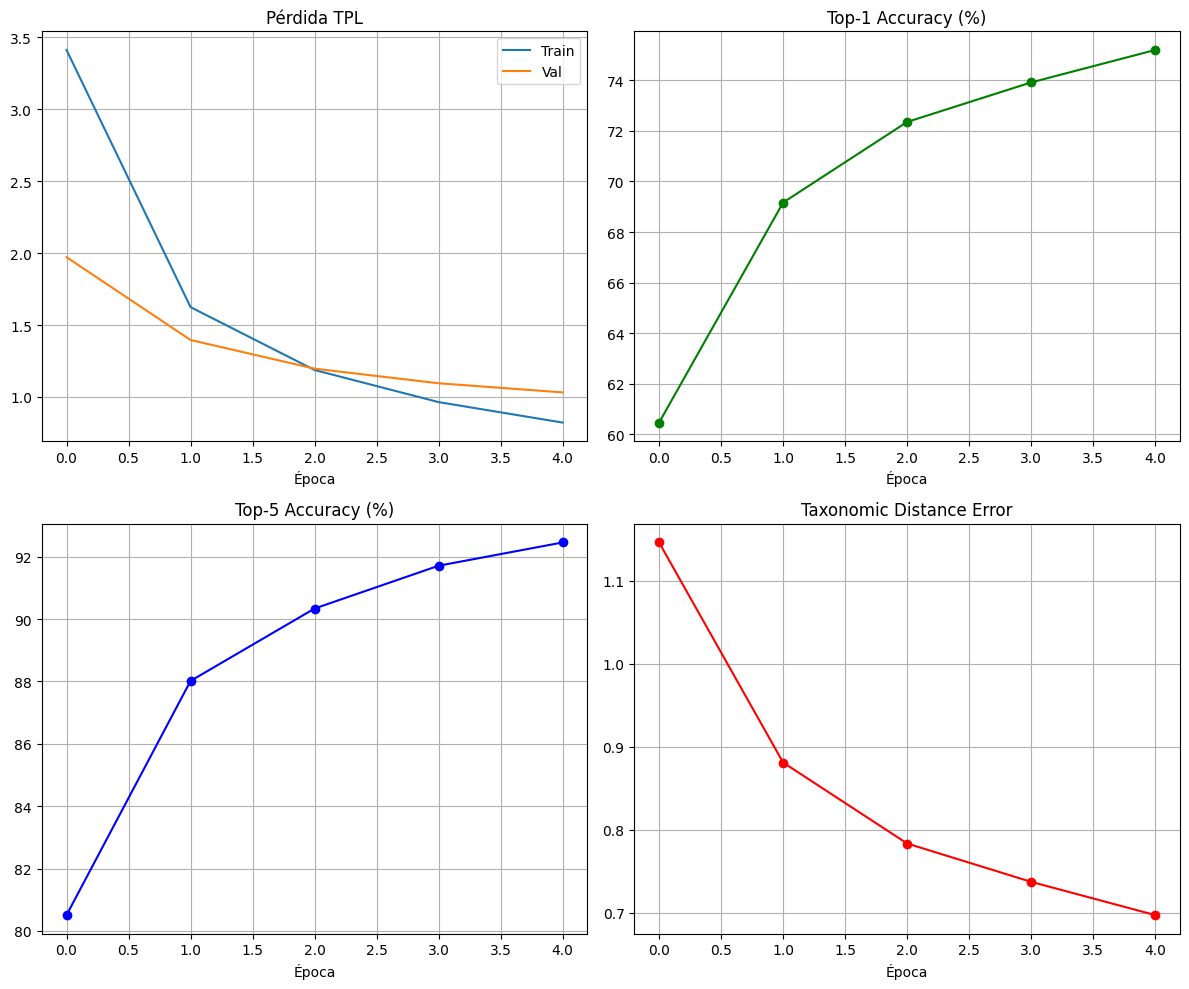

Gráfica guardada: training_metrics.png


In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Pérdida
axes[0, 0].plot(history['train_loss'], label='Train')
axes[0, 0].plot(history['val_loss'], label='Val')
axes[0, 0].set_title('Pérdida TPL')
axes[0, 0].set_xlabel('Época')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Top-1 Accuracy
axes[0, 1].plot([acc*100 for acc in history['top1_acc']], 'g-o')
axes[0, 1].set_title('Top-1 Accuracy (%)')
axes[0, 1].set_xlabel('Época')
axes[0, 1].grid(True)

# Top-5 Accuracy
axes[1, 0].plot([acc*100 for acc in history['top5_acc']], 'b-o')
axes[1, 0].set_title('Top-5 Accuracy (%)')
axes[1, 0].set_xlabel('Época')
axes[1, 0].grid(True)

# TDE
axes[1, 1].plot(history['tde'], 'r-o')
axes[1, 1].set_title('Taxonomic Distance Error')
axes[1, 1].set_xlabel('Época')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150)
plt.show()
print("Gráfica guardada: training_metrics.png")

## 14. (Opcional) Inferencia en una imagen

In [ ]:
import os
import json
import torch
import matplotlib.pyplot as plt
from PIL import Image

# 1. Cargar metadatos para mapear los nombres
names_path = os.path.join(ROOT_DIR, 'plantnet300K_species_names.json')
with open(names_path, 'r', encoding='utf-8') as f:
    species_names = json.load(f)

# Recrear el mapeo índice matemático -> species_id original
sorted_sids = sorted(int(k) for k in species_names.keys())
idx_to_sid = {idx: sid for idx, sid in enumerate(sorted_sids)}

def format_taxonomy(idx, original_sid):
    """Extrae Familia, Género y Especie visualmente"""
    # 'name' viene con formato 'Genero_especie_subespecie...'
    name = species_names.get(str(original_sid), f"Especie_{idx}")
    partes = name.split('_')
    
    genus_str = partes[0]
    species_str = " ".join(partes[1:]) if len(partes) > 1 else "Unknown" # Espacio en lugar de _
    
    # La Familia es sintética (un ID de bloque generado en Celda 5)
    # Por lo que usamos la variable global 'species_to_family'
    fid = species_to_family.get(idx, "?")
    
    return f"[Fam: {fid}] {genus_str} {species_str}"

def predict_and_show(image_path, true_species_idx, model, transform, device):
    """Muestra la imagen, su etiqueta real y las 5 mejores predicciones visuales"""
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        pred_f, pred_g, pred_s = model(input_tensor)
    
    probs = torch.softmax(pred_s, dim=1)
    top5_prob, top5_idx = torch.topk(probs, 5, dim=1)
    
    real_sid = idx_to_sid.get(true_species_idx)
    real_name_formatted = format_taxonomy(true_species_idx, real_sid)
    
    plt.figure(figsize=(7, 7))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Real: {real_name_formatted}\nArchivo: {os.path.basename(image_path)}", fontsize=12, pad=15)
    plt.show()

    print("-" * 75)
    print("TOP 5 PREDICCIONES DEL MODELO (Familia | Género | Especie):")
    print("-" * 75)
    for i in range(5):
        idx = top5_idx[0, i].item()
        prob = top5_prob[0, i].item() * 100
        
        predicted_sid = idx_to_sid.get(idx)
        name_formatted = format_taxonomy(idx, predicted_sid)
        
        marca = "✅" if idx == true_species_idx else "❌"
        
        print(f"{i+1}. {name_formatted}: {prob:.2f}% {marca}")
    print("-" * 75)

# --- EJECUCIÓN ---
if hasattr(train_dataset, 'dataset'): # Para el caso de usar el Subset (20%)
    real_idx = train_dataset.indices[0]
    sample_img_path, y_fam, y_gen, y_spec = train_dataset.dataset.samples[real_idx]
else: # Para el 100%
    sample_img_path, y_fam, y_gen, y_spec = train_dataset.samples[0]

# Ejecutar visualizador
predict_and_show(sample_img_path, y_spec, model, val_transform, DEVICE)